### Fill in group number and member names:

In [11]:
GROUP = "15"
NAME1 = "Aaron O'Malley"
NAME2 = "Gustav Fohlstedt"


# Optimization for learning - FRTN50

## Assignment 1

The goal of this assignment is to become familiar with some of the steps involved in solving an optimization problem. In this assignment, you will form Fenchel dual problems, find gradients and/or proximal operators, and implement the proximal gradient method.

__Problem__ The problem we will solve is the following constrained problem

\begin{align}
	\tag{1}
	\underset{x \in S}{\text{minimize}}\; \tfrac{1}{2}x^T Q x + q^Tx
\end{align}

where $Q\in\mathbb{S}_{++}^{n}$, $q\in\mathbb{R}^{n}$ and $S\subseteq\mathbb{R}^{n}$ is a set defined by the points $a,b\in\mathbb{R}^{n}$, $a\leq b$, such that 

\begin{equation*}
	S = \{x \in \mathbb{R}^{n}: a \leq x \leq b \}.
\end{equation*}

I.e., we are going to minimize a quadratic function over an $n$-dimensional box. Recall that, the vector inequality $a\leq b$ means that 

\begin{align*}
	a_{i} \leq b_{i}
\end{align*}

for each $i=1,\ldots,n$. Define the function $f:\mathbb{R}^{n}\rightarrow\mathbb{R}$ such that

\begin{align*}
	f(x) = \tfrac{1}{2}x^T Q x + q^Tx
\end{align*}

for each $x\in\mathbb{R}^{n}$ and let $\iota_{S}:\mathbb{R}^{n}\rightarrow\mathbb{R}\cup\{\infty\}$ denote the indicator function of the set $S$, i.e.,

\begin{align*}
	\iota_{S}(x) =
	\begin{cases}
		0 		& \text{if }x\in S, \\
		\infty 	& \text{if }x\in \mathbb{R}^n \setminus S.
	\end{cases}
\end{align*}

Problem $(1)$ can then be written as 

\begin{align}
	\tag{2}
	\underset{x \in \mathbb{R}^{n}}{\text{minimize}}\; f(x) + \iota_{S}(x).
\end{align}

__Solution method__ To solve optimization problem $(2)$, we will use the _proximal gradient method_. It solves problems of the form

\begin{align}
	\tag{3}
	\underset{x \in \mathbb{R}^{n}}{\text{minimize}}\; f(x) + g(x) 
\end{align}

where $f:\mathbb{R}^{n}\rightarrow\mathbb{R}$ is differentiable and $g:\mathbb{R}^{n}\rightarrow\mathbb{R}\cup\{\infty\}$ is proximable, i.e., $\operatorname{prox}_{\gamma g}$ can be cheaply computed. The proximal gradient method (with constant step-size) is given by:

- Pick some arbitrary initial guess $x^0\in\mathbb{R}^{n}$ and step-size $\gamma>0$.
- For $k=0,1,2\ldots$, let 
\begin{align}
\tag{4}
				x^{k+1} = \operatorname{prox}_{\gamma g}\left(x^k - \gamma \nabla f(x^k)\right).
\end{align}
- Stop when $x^k$ is deemed to have converged.

In this assignment, we simply run the proximal gradient method a large fixed number of iterations and plot the norm of the fixed-point residual $| \lvert x^{k+1} - x^k \rvert |_{2}$ (also known as the step-length), of each step to make sure it converges to zero. Since the experiments are run on a computer, zero means smaller than machine precision, which usually is around $10^{-15}$.

The step-size parameter $\gamma$ in the $(4)$ will affect the convergence. It should be tuned to the problem or chosen based on properties of $f$ and $g$. In particular, suppose that $f$ and $g$ are proper, closed and convex. 
If $f$ is $\beta$-smooth for some parameter $\beta>0$, the maximal step-size to guarantee convergence is $\gamma < \frac{2}{\beta}$.

Below are the tasks that you need to solve. Keep this in mind:
- The suggested exercises in the exercise compendium found on the Canvas course page, up until and including the chapter "Proximal gradient method - basics", is relevant for this assignment. 
- Carefully motivate every step in your calculations.
- Use __figures__ and __tables__ to motivate your answers.
- Figures must have appropriately labeled axes and must be referenced in the main text.
- Your code should be written in a quite general manner, i.e., if a question is slightly modified, it should only require slight modifications in your code as well. 
- Comment your code well. 
- Make sure you plot in such a way that small quantities (e.g., $|\lvert x^{k+1} - x^k \lvert|_2$) are visible. In particular, use log-linear plots, where the quantity that should go to $0$ is on the $y$-axis using logarithmic scale, and the iteration number $k$ on the $x$-axis using linear scale.
- What you need to submit to Canvas:
    - This jupyter notebook containing your solutions.
    - An exported pdf version of the jupyter notebook. (One way to do this is to print the notebook in your web browser, and then save as pdf.)

This table shows which lectures are needed in order to solve task 1-7:
    
| Task | Lectures |
| ---- | -------- |
| 1    | 2, 3     |
| 2    | 4        |
| 3    | 3, 4     |
| 4    | 2, 4     |
| 5    | 3, 4     |
| 6    | 5        |
| 7    | 4        |

Task 8-10 can be solved after you have solved task 1-7. 


---
### Task 1:

Show that $f$ and $\iota_{S}$ in $(2)$ are convex and show that constraint qualification (CQ) holds. You are allowed to assume that $\operatorname{relint} S \neq \emptyset$. Note that $f$ and $\iota_{S}$ also are closed, but you do not need to prove this.

__Solution:__ 

_Fill in your solution here!_

First, consider

$$
f(x)=\frac{1}{2}x^TQx+q^Tx.
$$

Its Hessian is

$$
\nabla^2 f(x)=Q.
$$

Since $(Q\in\mathbb{S}_{++}^n)$, we have $Q\succ0$. Hence $f$ is convex.

Next, we show that $S$ is convex since the indicator function of a convex set is also convex. Let $x,y\in S$ and let $\theta\in[0,1]$. Since

$$
a\leq x\leq b,\qquad a\leq y\leq b,
$$

we have, componentwise,

$$
a_i
=
\theta a_i+(1-\theta)a_i
\leq
\theta x_i+(1-\theta)y_i
\leq
\theta b_i+(1-\theta)b_i
=
b_i.
$$

Thus

$$
\theta x+(1-\theta)y\in S,
$$

so $S$ is convex. thus $\iota_S$ is convex.

Finally, the constraint qualification for $f+\iota_S$ is

$$
\operatorname{relint}(\operatorname{dom}f)
\cap
\operatorname{relint}(\operatorname{dom}\iota_S)
\neq\emptyset.
$$

Since $f$ is finite for every $x\in\mathbb{R}^n$,

$$
\operatorname{dom}f=\mathbb{R}^n,
$$

and from the definition of the indicator function,

$$
\operatorname{dom}\iota_S=S.
$$

Therefore,

$$
\operatorname{relint}(\operatorname{dom}f)
\cap
\operatorname{relint}(\operatorname{dom}\iota_S)
=
\mathbb{R}^n\cap\operatorname{relint}S
=
\operatorname{relint}S.
$$

By assumption, $\operatorname{relint}S\neq\emptyset$, so CQ holds.



---
### Task 2:

Compute the conjugate functions $f^\ast$ and $\iota_{S}^\ast$. The final expressions are not allowed to be given implicitly via optimization problems. E.g., projection formulas must be solved explicitly.

__Solution:__ 

_Fill in your solution here!_

For $f^*$ we need to calulate

$$
f^*(s) = \operatorname{sup}_{x \in \mathbb{R}^n}(s^Tx - f(x))
$$
Inserting $f$ gives
$$
\operatorname{sup}_{x \in \mathbb{R}^n}(s^Tx - f(x)) = \operatorname{sup}_{x \in \mathbb{R}^n}(s^Tx-\frac{1}{2}x^TQx-q^Tx) \\
\operatorname{sup}_{x \in \mathbb{R}^n}(s^Tx-\frac{1}{2}x^TQx-q^Tx) = \operatorname{sup}_{x \in \mathbb{R}^n}((s-q)^Tx - \frac{1}{2}x^TQx)
$$
We set the gradient to zero to find the maximizer
$$
s-q-Qx=0 \implies x = Q^{-1}(s-q)
$$
Resinserting this gives the resulting conjugate
$$
f^*(s) = \frac{1}{2}(s-q)^TQ^{-1}(s-q)
$$

Now for the indicator function we take
$$
\iota_S^*(s) = \operatorname{sup}_{x}(s^Tx - \iota_S(x))
$$
Because $\iota_S = \infty$ when $x \notin S$ we only have to consider
$$
\iota_S^*(s) = \operatorname{sup}_{x \in S}(s^Tx)
$$
When $s < 0$ the function is decreasing with $x$ so the maximum is attained for $x = a$ since $a < b$. On the contrary, if $s \geq 0$ the function is increasing with $x$ the maximum is attained at $x = b$ since $a < b$.
Thus
$$
\iota_S^*(s) = \sum_{i=1}^n\begin{cases}
b_i^Ts_i, \quad s \geq 0 \\
a_i^Ts_i, \quad s < 0

\end{cases}
$$


---
### Task 3:

Write down a Fenchel dual problem to $(2)$. Show that constraint qualification for the dual problem (CQ-D) holds.

_Attention/hint:_ Keep track of your minus signs.

__Solution:__ 

_Fill in your solution here!_

We write the primal problem as

$$
\min_x f(Lx)+g(x),
$$

The Fenchel dual is

$$
\min_{\mu\in\mathbb{R}^n}
f^*(\mu)+g^*(-L^T\mu).
$$

Since $L=I$ and $g=\iota_S$, this becomes

$$
\min_{\mu\in\mathbb{R}^n}
f^*(\mu)+\iota_S^*(-\mu).
$$

From Task 2,

$$
f^*(\mu)
=
\frac{1}{2}(\mu-q)^TQ^{-1}(\mu-q).
$$

Also,

$$
\iota_S^*(s)
=
\sum_{i=1}^n
\begin{cases}
b_i s_i, & s_i\geq 0,\\
a_i s_i, & s_i<0.
\end{cases}
$$

Setting $s=-\mu$ gives

$$
\iota_S^*(-\mu)
=
\sum_{i=1}^n
\begin{cases}
-b_i\mu_i, & \mu_i\leq 0,\\
-a_i\mu_i, & \mu_i>0.
\end{cases}
$$

Therefore the Fenchel dual is

$$
\min_{\mu\in\mathbb{R}^n}
\frac{1}{2}(\mu-q)^TQ^{-1}(\mu-q)
+
\sum_{i=1}^n
\begin{cases}
-b_i\mu_i, & \mu_i\leq 0,\\
-a_i\mu_i, & \mu_i>0.
\end{cases}
$$


---
### Task 4:

Show that $f$ and $f^*$ are $\beta$-, and $\beta^*$-smooth, respectively. Find expressions for the smallest such parameters $\beta$ and $\beta^*$. For instance, show that for any $\beta' < \beta$ we have that $f$ is not $\beta'$-smooth.

_Hint:_ Later when calculating the smoothness parameters in Pyhton, make sure to read the documentation carefully so that you use the correct function.

__Solution:__ 

_Fill in your solution here!_

For $f$ we have

$$
f(x)=\frac{1}{2}x^TQx+q^Tx,
\implies
\nabla f(x)=Qx+q.
$$

Thus

$$
\begin{aligned}
\|\nabla f(x)-\nabla f(y)\|_2
&=\|Q(x-y)\|_2 \\
&\leq \|Q\|_2\|x-y\|_2.
\end{aligned}
$$

Hence $f$ is $\beta$-smooth with

$$
\beta=\|Q\|_2.
$$

Since $Q$ is symmetric positive definite, its matrix $2$-norm is given by its largest eigenvalue. Therefore

$$
\beta=\lambda_{\max}(Q)
$$

and this is the smallest possible smoothness constant.

For the conjugate we have

$$
f^*(s)
=
\frac{1}{2}(s-q)^TQ^{-1}(s-q),
$$

which gives

$$
\nabla f^*(s)=Q^{-1}(s-q).
$$

Therefore

$$
\begin{aligned}
\|\nabla f^*(s)-\nabla f^*(t)\|_2
&=
\|Q^{-1}(s-t)\|_2 \\
&\leq
\|Q^{-1}\|_2\|s-t\|_2.
\end{aligned}
$$

Thus

$$
\beta^*=\|Q^{-1}\|_2.
$$

Since $Q^{-1}$ is also symmetric positive definite,

$$
\|Q^{-1}\|_2
=
\lambda_{\max}(Q^{-1})
=
\frac{1}{\lambda_{\min}(Q)}.
$$

Hence

$$
\beta^*
=
\frac{1}{\lambda_{\min}(Q)}
$$

and the smallest smoothness constants are therefore

$$
\beta=\lambda_{\max}(Q),
\qquad
\beta^*=\frac{1}{\lambda_{\min}(Q)}.

$$

For proving that $\beta' < \beta$ violates smoothness let $\beta=\lambda_{\max}(Q)$ and let $v_{\max}\neq 0$ be an eigenvector corresponding to $\lambda_{\max}(Q)$. Then

$$
Qv_{\max}=\beta v_{\max}.
$$

Choose $x,y$ such that

$$
x-y=v_{\max}.
$$

Then

$$
\begin{aligned}
\|\nabla f(x)-\nabla f(y)\|_2
&=\|Q(x-y)\|_2 \\
&=\|Qv_{\max}\|_2 \\
&=\|\beta v_{\max}\|_2 \\
&=\beta\|v_{\max}\|_2.
\end{aligned}
$$

Now let $\beta'<\beta$. For $f$ to be $\beta'$-smooth we would need

$$
\|\nabla f(x)-\nabla f(y)\|_2
\leq
\beta'\|x-y\|_2.
$$

But for the choice above,

$$
\beta\|v_{\max}\|_2
>
\beta'\|v_{\max}\|_2.
$$

Hence the smoothness inequality is violated. Therefore, for every $\beta'<\beta$, $f$ is not $\beta'$-smooth.


---
### Task 5:

Compute $\nabla f$, $\nabla f^\ast$, $\operatorname{prox}_{\gamma\iota_{S}}$ and $\operatorname{prox}_{\gamma\iota_{S}^\ast}$. The final expressions are not allowed to be given implicitly via optimization problems. E.g., projection formulas must be solved explicitly.


__Solution:__ 

_Fill in your solution here!_

We already calculated $\nabla f$ and $\nabla f^*$ as $\nabla f(x)=Qx+q$ and $\nabla f^* = Q^{-1}(s-q)$

For the indicator function,

$$
\operatorname{prox}_{\gamma\iota_S}(z)
=
\arg\min_{x\in S}\|x-z\|_2^2,
$$

since $\iota_S = \infty$ outside $S$ it is the projection onto the box $S$ componentwise,

$$
[\operatorname{prox}_{\gamma\iota_S}(z)]_i
=
\begin{cases}
a_i, & z_i<a_i,\\
z_i, & a_i\le z_i\le b_i,\\
b_i, & z_i>b_i.
\end{cases}
$$

For $\iota_S$ we use Moreau decomposition,

$$
\operatorname{prox}_{\gamma\iota_S^*}(z)
=
z-\gamma\operatorname{prox}_{\iota_S}(z/\gamma).
$$

Since we already know $\operatorname{prox}_{\iota_S}$ multiplying by $\gamma$ then subtracting from $z_i$ along with adjusting the bounds for $z_i/\gamma$ yields the following

$$
[\operatorname{prox}_{\gamma\iota_S^*}(z)]_i
=
\begin{cases}
z_i-\gamma a_i, & z_i<\gamma a_i,\\
0, & \gamma a_i\le z_i\le\gamma b_i,\\
z_i-\gamma b_i, & z_i>\gamma b_i.
\end{cases}
$$


### Task 6:

Based on your results above, write explicitly out the proximal gradient update rule $(4)$ for both the primal and the dual problem. Use $x$ as the primal variable and $\mu$ as the dual variable.

_Attention/hint:_ Keep track of your minus signs.

__Solution:__ 

_Fill in your solution here!_

If we take our result from Task 6 for $\operatorname{prox}_{\gamma \iota_S}$ and take 
$$
z^k=x^k -\gamma(Qx^k+q)
$$
We get:
$$
x_i^{k+1}
=
\begin{cases}
a_i, & z_i^k<a_i,\\
z_i, & a_i\le z_i^k\le b_i,\\
b_i, & z_i^k>b_i.
\end{cases}
$$

We do the same for the dual problem, but we instead use $\operatorname{prox}_{\gamma \iota_S^*}$ as well as $w^k = \mu^k - \gamma Q^{-1}(\mu^k-q)$ which gives

$$
\mu_i^{k+1}
=
\begin{cases}
w_i^k-\gamma a_i, & w_i^k<\gamma a_i,\\
0, & \gamma a_i\le w_i^k\le\gamma b_i,\\
w_i^k-\gamma b_i, & w_i^k>\gamma b_i.
\end{cases}
$$




---
### Task 7:

Suppose that $\mu^\star\in\mathbb{R}^{n}$ is an optimal solution to the dual problem you found in Task 3. Given $\mu^\star$, and __starting from the optimality condition for the dual problem (given by _Fermat's rule_)__, recover an optimal point $x^{\star}\in\mathbb{R}^{n}$ to the primal problem $(2)$, and show that this $x^{\star}$ is in fact an optimal solution to the primal problem (2). Motivate each step in your argument carefully.

__Solution:__ 

_Fill in your solution here!_

Fermats rule says that if \mu* minimizes the dual problem

$$
0 \in \partial\left(f^*(\mu*)+\iota_S^*(-\mu*)\right)
$$

And with previous result from task 5 we knot $f*$ is differentiable,

$$
\partial f^*(\mu^\star)=\{\nabla f^*(\mu^\star)\}
$$

and the second term, taking into account that $-\mu$ is the argument,
 $$
\partial\left(\iota_S^*(-\mu)\right)
=
-\partial \iota_S^*(-\mu)
$$
and the optimality condition becomes

$$
0 \in \nabla f^*(\mu^\star)-\partial \iota_S^*(-\mu^\star)
$$

Since we know that there exists a subgradient, $s \in \partial \iota_S^*(-\mu^\star)$ such that

$$
s=\nabla f^*(\mu^\star)
$$
and we define the recovered primal point using the result from task 5 combined with the derivation above as

$$
x^\star := \nabla f^*(\mu^\star) = Q^{-1}(\mu^{\star} - q).
$$

Showing that $x^{\star}$ is in fact an optimal solution to the primal problem:

With $x^\star = \nabla f^*(\mu^\star)$ and $x^\star \in \partial \iota_S^*(-\mu^\star)$ and with

$$
\mu \in \partial f(x)
\quad \Longleftrightarrow \quad
x \in \partial f^*(\mu
)
$$

we get

$$
\mu^\star \in \partial f(x^\star)
$$

and since $f$ is differentiable

$$
\mu^{\star} = \nabla f(x^{\star}) = Qx^{\star} + q
$$

combining this with the optimal point $x^\star = Q^{-1}(\mu^\star-q)$ we get 
$$
\nabla f(x^\star)
=
Qx^\star+q
=
QQ^{-1}(\mu^\star-q)+q
=
\mu^\star.
$$

That verifies the $f$-part of the primal optimality condition

For the indicator function, $\iota_S$ we had
$$
x^\star \in \partial \iota_S^*(-\mu^\star)
$$
Again using 

$$
\mu \in \partial f(x)
\quad \Longleftrightarrow \quad
x \in \partial f^*(\mu
)
$$

this gives

$$
-\mu^\star \in \partial \iota_S(x^\star)
$$

Combining the two condition $\mu^\star \in \partial f(x^\star)$ and $-\mu^\star \in \partial \iota_S(x^\star)$ gives 

$$
\mu^\star + (-\mu^\star)=0.
$$

Therefore

$$
0 \in \partial f(x^\star)+\partial \iota_S(x^\star).
$$

Using the subdifferential sum rule,

$$
\partial(f+\iota_S)(x^\star)
=
\partial f(x^\star)
+
\partial \iota_S(x^\star),
$$

so

$$
0 \in \partial(f+\iota_S)(x^\star)
$$

By Fermat's rule,

$$
0 \in \partial(f+\iota_S)(x^\star)
\quad \Longleftrightarrow \quad
x^\star \in \arg\min_x \left(f(x)+\iota_S(x)\right).
$$

Therefore $x^\star$ is an optimal solution to the primal problem.


--- 
### Task 8:

Use your results above to fill in the functions below.

__Solution:__ 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def quad(x,Q,q):
    """
    quad(x,Q,q) computes the quadratic function (1/2)x'Qx + q'x
    
    :param x: the variable of the quadratic function
    :param Q: the matrix in the quadratic function that corresponds to the quadratic form
    :param q: the vector in the quadratic function that corresponds to the linear part
    :return: (1/2)x'Qx + q'x
    """
    # Write your solution here
    return 0.5 * x.T @ Q @ x + q.T @ x

def quadconj(mu,Q,q):
    """
    quadconj(mu,Q,q) computes the conjugate function of the 
    quadratic function (1/2)x'Qx + q'x, evaluated at mu
    
    :param mu: the variable of the conjugate function
    :param Q: the matrix in the quadratic function that corresponds to the quadratic form
    :param q: the vector in the quadratic function that corresponds to the linear part
    :return: conjugate of (1/2)x'Qx + q'x, evaluated at mu
    """
    # Write your solution here
    v = mu - q
    return 0.5 * v.T @ np.linalg.solve(Q, v)

def box(x,a,b, tol=0.0):
    """
    box(x,a,b) computes the indicator function of the box contraint
    [a,b]
    
    :param x: the variable of the indicator function
    :param a: the left vector defining the box contraint
    :param b: the right vector defining the box contraint
    :return: 0 if x is in [a,b] and infinity otherwise
    """
    if np.all(a  - tol <= x) and np.all(x  <= b + tol):
        return 0
    else: 
        return np.inf

def boxconj(mu,a,b):
    """
    boxconj(mu,a,b) computes the conjugate function of the indicator function 
    of the box contraint [a,b], evaluated at mu
    
    :param mu: the variable of the conjugate function
    :param a: the left vector defining the box contraint
    :param b: the right vector defining the box contraint
    :return: conjugate of the indicator function of the box contraint [a,b], evaluated at mu
    """
    # Write your solution here
    iota = 0.0
    for i in range(len(mu)):
        if mu[i] >= 0:
            iota += b[i] * mu[i]
        else:
            iota += a[i] * mu[i]
    return iota

def grad_quad(x,Q,q):
    """
    grad_quad(x,Q,q) computes the gradient of the quadratic function (1/2)x'Qx + q'x
    
    :param x: the variable of the quadratic function
    :param Q: the matrix in the quadratic function that corresponds to the quadratic form
    :param q: the vector in the quadratic function that corresponds to the linear part
    :return: gradient of (1/2)x'Qx + q'x
    """
    # Write your solution here
    return Q @ x + q

def grad_quadconj(mu,Q,q):
    """
    grad_quadconj(mu,Q,q) computes the gradient of the conjugate function of the 
    the quadratic function (1/2)x'Qx + q'x, evaluated at mu
    
    :param mu: the variable of the conjugate function
    :param Q: the matrix in the quadratic function that corresponds to the quadratic form
    :param q: the vector in the quadratic function that corresponds to the linear part
    :return: gradient of the conjugate of (1/2)x'Qx + q'x, evaluated at mu
    """
    # Write your solution here
    v = mu - q
    return np.linalg.solve(Q, v)

def prox_box(x,a,b,gamma):
    """
    prox_box(x,a,b,gamma) computes proximal operator of the indicator function 
    of the box contraint [a,b], evaluated at x
    
    :param x: the variable of the poximal operator
    :param a: the left vector defining the box contraint
    :param b: the right vector defining the box contraint
    :param gamma: the step-size parameter
    :return: proximal operator of the indicator function of the 
    box contraint [a,b], evaluated at x
    """
    # Write your solution here
    prox = []
    for i in range(len(x)):
        prox.append(
            a[i] if x[i] < a[i]
            else x[i] if x[i] <= b[i]
            else b[i])
    return np.array(prox)

def prox_boxconj(mu,a,b,gamma):
    """
    prox_box(mu,a,b,gamma) computes proximal operator of the conjugate function of 
    the indicator function of the box contraint [a,b], evaluated at mu
    
    :param mu: the variable of the poximal operator
    :param a: the left vector defining the box contraint
    :param b: the right vector defining the box contraint
    :param gamma: the step-size parameter
    :return: proximal operator of the conjugate function of the indicator function of the 
    box contraint [a,b], evaluated at mu
    """
    # Write your solution here
    prox = []
    for i in range(len(mu)):
        prox.append(
            mu[i] - gamma * a[i] if mu[i] < gamma * a[i]
            else 0 if mu[i] <= gamma * b[i]
            else mu[i] - gamma * b[i])
    return np.array(prox)

def dual_to_primal(mu,Q,q,a,b):
    """
    dual_to_primal(mu,Q,q,a,b) computes the solution x* to the primal problem 
    given a solution mu* to the dual problem.
    
    :param mu: the dual variable
    :param Q: the matrix in the quadratic function that corresponds to the quadratic form
    :param q: the vector in the quadratic function that corresponds to the linear part
    :param a: the left vector defining the box contraint
    :param b: the right vector defining the box contraint
    :return: the extracted primal variable
    """
    x_star = np.linalg.solve(Q, mu-q)
    return x_star
    #if np.all(x_star <= b) and np.all(x_star >= a):
    #    return x_star
    #return None


---
### Task 9:

Below is a function for generating $Q$, $q$, $a$, and $b$ that define the quadratic function $f$ and the box constraint set $S$. Use Task 8 to solve the primal problem using the proximal gradient method.

In [13]:
def problem_data():
    """
    problem_data() generates the problem data variables Q, q, a and b
    
    :return: (Q,q,a,b)
    """
    rs = np.random.RandomState(np.random.MT19937(np.random.SeedSequence(1)))
    n = 20
    Q = rs.randn(n,n)
    Q = Q.T@Q
    q = rs.randn(n)
    a = -rs.rand(n)
    b = rs.rand(n)
    return Q, q, a, b

(Q,q,a,b) = problem_data()

gamma = 0.5/beta converged to
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.02685467
 -0.02776544  0.0413215   0.39778617  0.50334775  0.04773959  0.07163752
 -0.0167408  -0.39799663  0.02749792  0.18934824  0.01631368 -0.39400725
  0.52482998  0.28689621]

gamma = 1/beta converged to
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.02685467
 -0.02776544  0.0413215   0.39778617  0.50334775  0.04773959  0.07163752
 -0.0167408  -0.39799663  0.02749792  0.18934824  0.01631368 -0.39400725
  0.52482998  0.28689621]

gamma = 1.5/beta converged to
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.02685467
 -0.02776544  0.0413215   0.39778617  0.50334775  0.04773959  0.07163752
 -0.0167408  -0.39799663  0.02749792  0.18934824  0.01631368 -0.39400725
  0.52482998  0.28689621]

gamma = 1.9/beta converged to
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.02685467
 -0.02776544  0.0413215   0.39778617  0.50334775  0.04773959  0.0716375

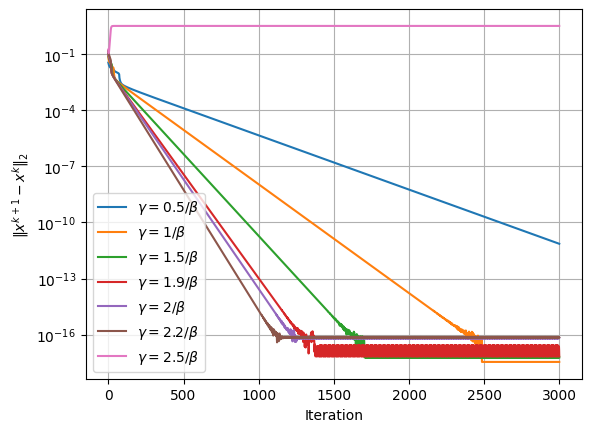

In [14]:
x0 = np.zeros(len(q))
def prox_grad_method(x0, Q, q, a, b, gamma):
    allx = [x0.copy()]

    residuals = []

    for _ in range(3000):
        xnew = prox_box(x0 - gamma * grad_quad(x0, Q, q), a, b, gamma) 
        residuals.append(np.linalg.norm(xnew - x0))
        allx.append(xnew.copy())
        x0 = xnew

    return x0, np.array(allx), np.array(residuals)

beta = np.linalg.norm(Q, 2)

results = {}
for numerator in [0.5, 1, 1.5, 1.9, 2.0, 2.2, 2.5]:
    x_final, xs, residuals = prox_grad_method(
        x0, Q, q, a, b, numerator / beta
    )
    results[numerator] = x_final.copy()
    print(f"gamma = {numerator:g}/beta converged to")
    print(x_final)
    print()
    plt.semilogy(residuals, label=fr"$\gamma = {numerator:g}/\beta$")

plt.xlabel("Iteration")
plt.ylabel(r"$\|x^{k+1}-x^k\|_2$")
plt.legend()
plt.grid()
plt.show()

__a)__ What seems to be the best choice of $\gamma$? 

__Solution:__ 

_Fill in your solution here!_

The algorithm seems to converge for values of gamme between 0.5/beta -> ~2.2/beta, with the 2.2/beta converging quickest.



__b)__ Does the upper bound $\gamma < \frac{2}{\beta}$ seem reasonable?

__Solution:__ 

_Fill in your solution here!_

Yes it seems reasonable, though perhaps the starting point now allows the range to be slightly larger all the way up to 2.2.



Test different initial points for the algorithm:

__c)__ Does this affect the point the algorithm converges to? 

__Solution:__ 

_Fill in your solution here!_

Start 1:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Converged to:
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.02685467
 -0.02776544  0.0413215   0.39778617  0.50334775  0.04773959  0.07163752
 -0.0167408  -0.39799663  0.02749792  0.18934824  0.01631368 -0.39400725
  0.52482998  0.28689621]

Start 2:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Converged to:
[ 0.27631373 -0.01853066  0.49151296  0.10348766 -0.14574171 -0.11139898
 -0.05988096  0.25121204  0.13763283  0.55382616  0.1311185   0.17425473
  0.26645228 -0.52513654  0.38821612  0.30809035  0.01631368 -0.64924006
 -0.21177808  0.08357806]

Start 3:
[-0.16006205  0.19299592  0.25558473 -0.11559033  0.56783969 -0.14998964
 -0.24801493  0.46468449  0.42314727  0.5280051   0.24100364 -0.17652262
 -0.18829286 -0.48794997  0.10207131  0.29955097 -0.05876678  0.00616308
  0.25610389 -0.0099474 ]
Converged to:
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.026854

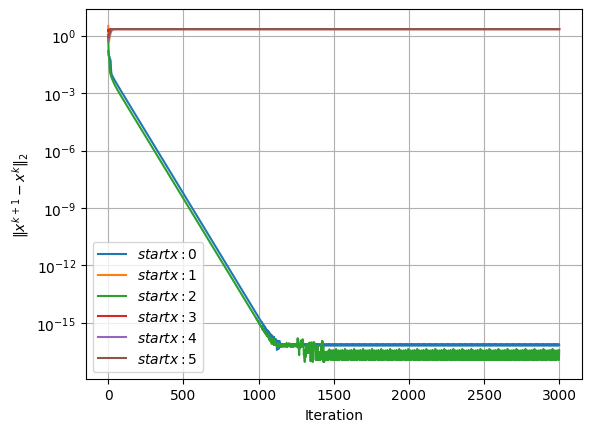

In [15]:
# Write your solution here
x0s = [
    np.zeros(len(q)),
    np.ones(len(q)),
    np.random.uniform(a, b),
    np.random.uniform(a, b),
    np.random.uniform(a, b),
    np.random.uniform(a, b),
]

gamma = 2.2 / beta # to be safe

for i, x0 in enumerate(x0s):
    x_final, xs, residuals = prox_grad_method(
        x0, Q, q, a, b, gamma
    )
    plt.semilogy(residuals, label=fr"$start x : {i}$")

    print(f"Start {i+1}:")
    print(x0)
    print("Converged to:")
    print(x_final)
    print()

plt.xlabel("Iteration")
plt.ylabel(r"$\|x^{k+1}-x^k\|_2$")
plt.legend()
plt.grid()
plt.show()

Start 1:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Converged to:
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.02685467
 -0.02776544  0.0413215   0.39778617  0.50334775  0.04773959  0.07163752
 -0.0167408  -0.39799663  0.02749792  0.18934824  0.01631368 -0.39400725
  0.52482998  0.28689621]

Start 2:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Converged to:
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.02685467
 -0.02776544  0.0413215   0.39778617  0.50334775  0.04773959  0.07163752
 -0.0167408  -0.39799663  0.02749792  0.18934824  0.01631368 -0.39400725
  0.52482998  0.28689621]

Start 3:
[ 0.85781675  0.73842653 -0.64549891 -0.06448094  0.26499864  0.11204364
  0.36712332  0.43542482  0.31414402 -0.13041229 -0.34354046  0.0795512
  0.01205087 -0.01524723  0.27859097 -0.15678845 -0.07490407 -0.8467278
  0.19086707 -0.00814139]
Converged to:
[-0.25374054  0.22842393  0.25765564 -0.2089593   0.14902594 -0.02685467

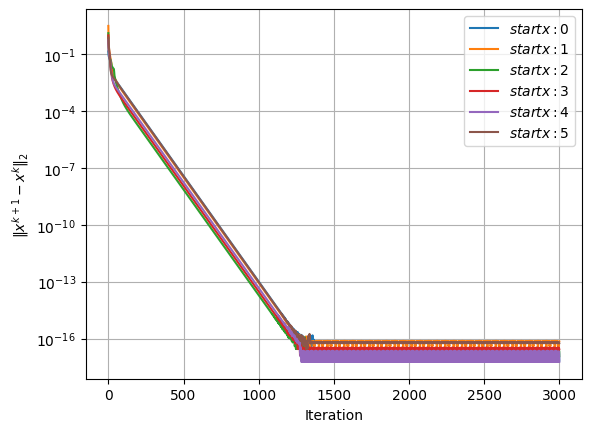

In [16]:
# Write your solution here
x0s = [
    np.zeros(len(q)),
    np.ones(len(q)),
    np.random.uniform(a, b),
    np.random.uniform(a, b),
    np.random.uniform(a, b),
    np.random.uniform(a, b),
]

gamma = 1.9 / beta # to be safe

for i, x0 in enumerate(x0s):
    x_final, xs, residuals = prox_grad_method(
        x0, Q, q, a, b, gamma
    )
    plt.semilogy(residuals, label=fr"$start x : {i}$")

    print(f"Start {i+1}:")
    print(x0)
    print("Converged to:")
    print(x_final)
    print()

plt.xlabel("Iteration")
plt.ylabel(r"$\|x^{k+1}-x^k\|_2$")
plt.legend()
plt.grid()
plt.show()

As we can see they all converge to same x, but now we can see that 2.2/beta no longer yields convergence for all x0, so the <2/beta seems reasonable now.


__d)__ Carefully motivate theoretically why/why not it affects the final point. _Hint:_ Look at the objective function in $(2)$.

__Solution:__ 

_Fill in your solution here!_

Since $Q\succ0$, the quadratic function

$$
f(x)=\frac{1}{2}x^TQx+q^Tx
$$

is strictly convex. The indicator function $\iota_S$ is convex, so the objective

$$
f(x)+\iota_S(x)
$$

is strictly convex on $S$. Hence the primal problem has a unique minimizer $x^\star$. Therefore, as long as the proximal gradient method converges, the choice of initial point only affects the path and speed, not the final point.


__e)__ Does your final point $x^{\text{final}}$ satisfy the constraint $x^{\text{final}} \in S$?

__Solution:__ 

_Fill in your solution here!_

In [24]:
# Write your solution here
for i in range(len(x_final)):
    if x_final[i] < a[i] or x_final[i] > b[i]:
        print("NOT IN S")
        break
else:
    print("IN S")
    
# x_final is in S !!

IN S



__f)__ What about the iterates, do they always satisfy the constraint, $x^k \in S$? Why/why not?

__Solution:__ 

_Fill in your solution here!_

In [18]:
for x in xs:
    for i in range(len(x)):
        if x[i] < a[i] or x[i] > b[i]:
            print("NOT IN S")
            break
else:
    print("IN S")

# all xk are in S !!

IN S



---
### Task 10:

Solve the dual problem. 

__a)__ Similar to the previous task, find/verify the upper bound on the step-size and find a good step-size choice.

__Solution:__ 

_Fill in your solution here!_

gamma = 0.1/beta* converged to
[ 1.17753726 -0.         -0.          1.1932681  -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.60141629 -0.
 -1.56889114 -0.88336277]

gamma = 0.5/beta* converged to
[ 1.17512072 -0.         -0.          1.19820935 -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.59746159 -0.
 -1.57000462 -0.88243539]

gamma = 1/beta* converged to
[ 1.17512072 -0.         -0.          1.19820935 -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.59746159 -0.
 -1.57000462 -0.88243539]

gamma = 1.5/beta* converged to
[ 1.17512072 -0.         -0.          1.19820935 -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.59746159 -0.
 -1.57000462 -0.8

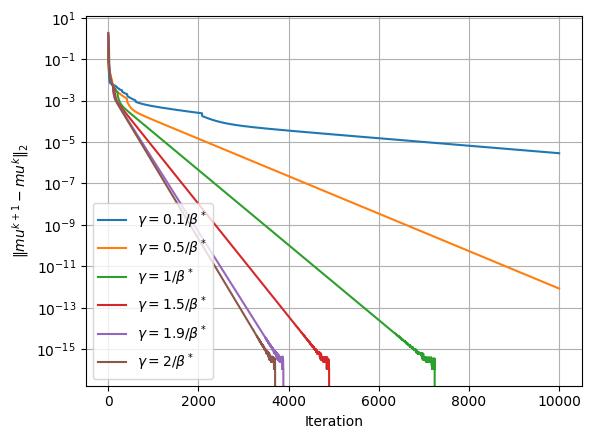

In [19]:
# Write your solution here
mu0 = np.zeros(len(q))
def prox_grad_method_conj(mu0, Q, q, a, b, gamma):
    mu = mu0.copy()
    allmu = [mu.copy()]

    residuals = []

    for _ in range(10000):
        w = mu - gamma * grad_quadconj(mu, Q, q)
        munew = -prox_boxconj(-w, a, b, gamma) 
        residuals.append(np.linalg.norm(munew - mu))
        allmu.append(munew.copy())
        mu = munew

    return mu, np.array(allmu), np.array(residuals)

beta_conj = np.linalg.norm(np.linalg.inv(Q), 2)

results_conj = {}
for numerator in [0.1, 0.5, 1, 1.5, 1.9, 2.0]:
    mu_final, allmu, residuals = prox_grad_method_conj(
        mu0, Q, q, a, b, numerator / beta_conj
    )
    results_conj[numerator] = mu_final.copy()
    print(f"gamma = {numerator:g}/beta* converged to")
    print(mu_final)
    print()
    plt.semilogy(residuals, label=fr"$\gamma = {numerator:g}/\beta^*$")

plt.xlabel("Iteration")
plt.ylabel(r"$\|mu^{k+1}-mu^k\|_2$")
plt.legend()
plt.grid()
plt.show()

Roughly same as last time, 2/beta still converges but 1.9 is probably better choice for different mu0.


Let $x^{\text{final}}$ be the final points from Task 9 and $\mu^{\text{final}}$ the final point for the dual problem. Let $\hat{x}^{\text{final}}$ final primal points extracted from the final dual point $\mu^{\text{final}}$ using the expression from Task 7:

__b)__ Are $x^{\text{final}}$ and $\hat{x}^{\text{final}}$ the same?

__Solution:__ 

_Fill in your solution here!_

In [20]:
# Write your solution here
mu_final = results_conj[1.9]
x_final = results[1.9]
x_hat_final = np.linalg.inv(Q) @ (mu_final - q)
print(np.allclose(x_final, x_hat_final))
print("Maximum difference:", np.max(np.abs(x_final - x_hat_final)))

True
Maximum difference: 2.7200464103316335e-15


Yes they are the same.

We did not use the dual_to_primal because it gives None and this was a quicker fix since the small errors 1e-15 caused errors but do not actually impact our results.


__c)__ Is $\hat{x}^{\text{final}}$ in the box $S$?

__Solution:__ 

_Fill in your solution here!_

In [26]:
# Write your solution here
# well yes since it is the same as xfinal but we will check

tolerance = 0.5*1e-14

for i in range(len(x_hat_final)):
    if np.isfinite(box(x_hat_final, a, b, tol=tolerance)):
        print("x_hat_final is in S")
    else:
        print("x_hat_final is not in S")
# x_hat_final is in S !! some small numerical difference but tolerance is so low
# that its acceptable

x_star_final = dual_to_primal(mu_final, Q, q, a, b)

lower_violation = np.maximum(a - x_hat_final, 0)
upper_violation = np.maximum(x_hat_final - b, 0)

print("Maximum constraint violation:",
      max(np.max(lower_violation), np.max(upper_violation)))

x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
x_hat_final is in S
Maximum constraint violation: 1.3322676295501878e-15



__d)__ Let $\mu^k$ be the iterates of the dual method, using the expression from Task 7, extract the primal iterates $\hat{x}^k$ from $\mu^k$. Does $\hat{x}^k$ always satisfy the constraint $\hat{x}^k \in S$?

__Solution:__ 

_Fill in your solution here!_

In [28]:
# Write your solution here
tolerance = 1e-14
num_in_S = 0
num_violations = 0
for mu in allmu:
    x_hat = np.linalg.solve(Q, mu - q)

    if np.all((x_hat >= a - tolerance) & (x_hat <= b + tolerance)):
        num_in_S += 1
    else:
        num_violations += 1

print("x_hat in S:", num_in_S)
print("x_hat not in S:", num_violations)
# all the xhatk are NOT in S !!

x_hat in S: 6611
x_hat not in S: 3390



__e)__ How do the function values $f\left(\hat{x}^k\right)$ develop over the iterations?

__Solution:__ 

_Fill in your solution here!_

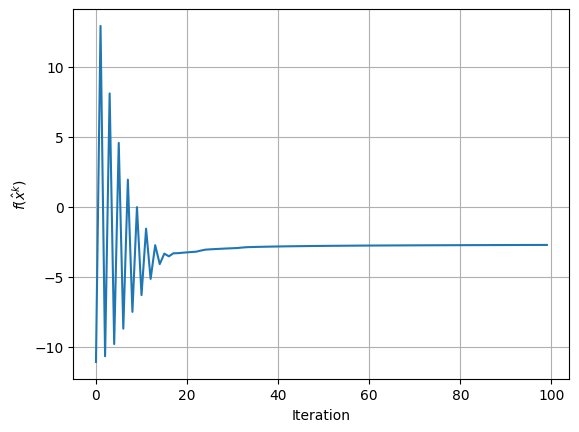

In [ ]:
# Write your solution here

mu_final, allmu, residuals = prox_grad_method_conj(
    mu0, Q, q, a, b, 1.9 / beta_conj
)

f_vals = []
for mu in allmu[:100]:
    x_hat = np.linalg.solve(Q, (mu - q))
    f_vals.append(quad(x_hat, Q, q))

plt.plot(f_vals)
plt.xlabel("Iteration")
plt.ylabel(r"$f(\hat{x}^k)$")
plt.grid()
plt.show()

# all the xhatk are NOT in S !!


__f)__ What about $f\left(\hat{x}^k\right)+\iota_{S}\left(\hat{x}^k\right)$?

__Solution:__ 

_Fill in your solution here!_

In [36]:
vals = []
for mu in allmu[:100]:
    x_hat = dual_to_primal(mu, Q, q, a, b)
    vals.append(quad(x_hat, Q, q) + box(x_hat, a, b, tol=1e-6))

vals = np.array(vals)
it = np.arange(len(vals))
finite = np.isfinite(vals)

plt.plot(it[finite], vals[finite], '.-')
plt.xlabel('iteration k')
plt.ylabel(r'$f(\hat{x}^k) + \iota_S(\hat{x}^k)$')
plt.show()
print(np.sum(np.isfinite(vals)))

AttributeError: 'NoneType' object has no attribute 'T'